### Disclaimer
In this notebook, most of the code was generated by an AI model and the text was rephrased by an AI, but the conceptualization and idealization of the analysis and modeling strategies were provided by me.

# Sixt Data Science Lab - Test Task for Data Scientist Job Candidates

## Introduction

In this test task you will have an opportunity to demonstrate your skills of a Data Scientist from various angles - processing data, analyzing and vizalizing it, finding insights, applying predictive techniques and explaining your reasoning about it.

The task is based around a bike sharing dataset openly available at UCI Machine Learning Repository [1].

Please go through the steps below, build up the necessary code and comment on your choices.

## Part 1 - Data Loading and Environment Preparation

**Tasks:**
1. Prepare a Python 3 virtual environment (with virtualenv command). requirements.txt output of pip freeze command should be included as part of your submission.
2. Load the data from UCI Repository and put it into the same folder with the notebook. The link to it is https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset . Here is an available mirror in case the above website is down: https://data.world/uci/bike-sharing-dataset
3. We split the data into two parts. One dataset containing the last 30 days and one dataset with the rest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# read raw data
df_all = pd.read_csv('day.csv')

# split dataset
df_last30 = df_all.tail(30)
df = df_all.iloc[:-30, :].copy() # Explicitly create a copy to avoid SettingWithCopyWarning

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Part 2 - Data Processing and Analysis

**Tasks:**
1. Perform all needed steps to load and clean the data. Please comment the major steps of your code.
2. Visualise rentals of bikes per day.
3. Assume that each bike has exactly maximum 12 rentals per day.
    * Find the maximum number of bicycles `nmax` that was needed in any one day.
    * Find the 95%-percentile of bicycles `n95` that was needed in any one day.
5. Visualize the distribution of the covered days depending on the number of available bicycles (e.g. `nmax` bicycles would cover 100% of days, `n95` covers 95%, etc.)


### Data Cleaning Steps

I'll convert the 'dteday' column to a datetime object and set it as the DataFrame's index. This is crucial for time-series analysis and plotting. I'll also convert several numerical columns that represent categories (season, year, month, holiday, weekday, workingday, weathersit) into proper categorical types for better data representation and potential use in modeling.

In [2]:
# Convert 'dteday' to datetime and set as index
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.set_index('dteday')

# Convert 'instant' to string as it might be an identifier
df['instant'] = df['instant'].astype(str)

# Convert relevant columns to categorical type
# 'yr' should be treated as a categorical feature, as it represents year 0 (2011) and 1 (2012)
df['season'] = df['season'].astype('category')
df['yr'] = df['yr'].astype('category')
df['mnth'] = df['mnth'].astype('category')
df['holiday'] = df['holiday'].astype('category')
df['weekday'] = df['weekday'].astype('category')
df['workingday'] = df['workingday'].astype('category')
df['weathersit'] = df['weathersit'].astype('category')

print("DataFrame after data type conversions:")
display(df.info())

DataFrame after data type conversions:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 701 entries, 2011-01-01 to 2012-12-01
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   instant     701 non-null    object  
 1   season      701 non-null    category
 2   yr          701 non-null    category
 3   mnth        701 non-null    category
 4   holiday     701 non-null    category
 5   weekday     701 non-null    category
 6   workingday  701 non-null    category
 7   weathersit  701 non-null    category
 8   temp        701 non-null    float64 
 9   atemp       701 non-null    float64 
 10  hum         701 non-null    float64 
 11  windspeed   701 non-null    float64 
 12  casual      701 non-null    int64   
 13  registered  701 non-null    int64   
 14  cnt         701 non-null    int64   
dtypes: category(7), float64(4), int64(3), object(1)
memory usage: 55.5+ KB


None

### Visualize Rentals of Bikes Per Day

Now, I'll visualize the total count of bike rentals (`cnt`) over time to observe daily trends.

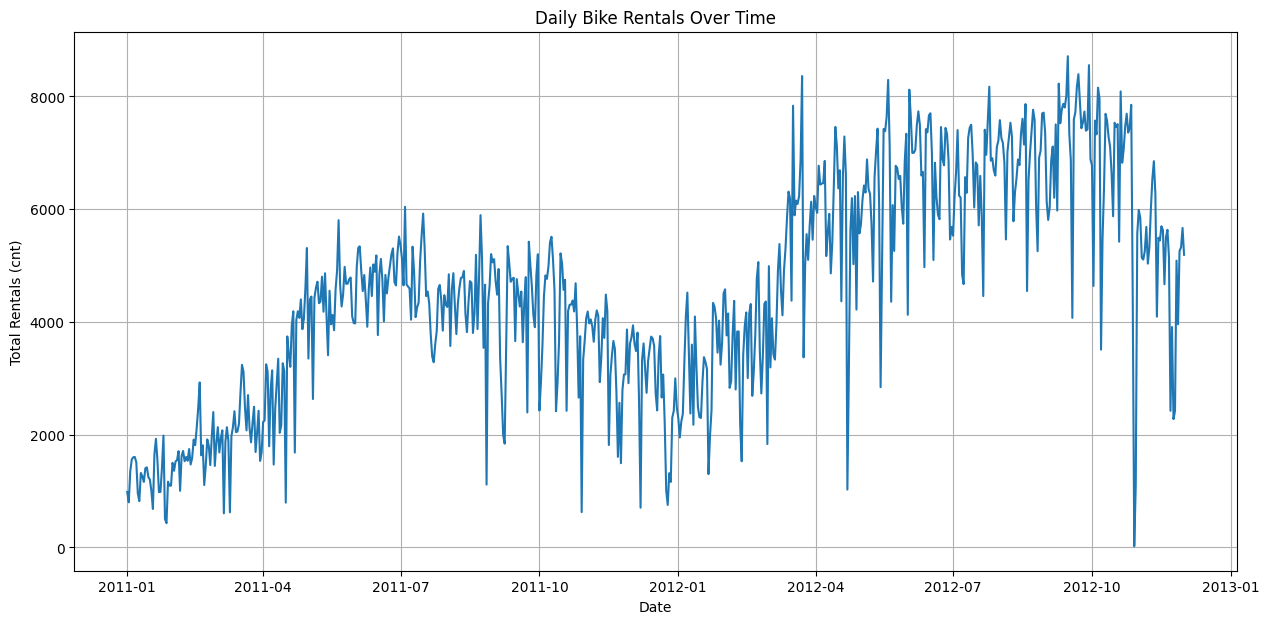

In [3]:
# Plot daily bike rentals
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x=df.index, y='cnt')
plt.title('Daily Bike Rentals Over Time')
plt.xlabel('Date')
plt.ylabel('Total Rentals (cnt)')
plt.grid(True)
plt.show()

### Calculate `nmax` and `n95`

Given the assumption that each bike has a maximum of 12 rentals per day, I will calculate the number of bikes needed for each day by dividing the total rentals (`cnt`) by 12. Then, I'll find the maximum (`nmax`) and the 95th percentile (`n95`) of these daily bike requirements.

In [4]:
# Calculate the number of bikes needed per day
df['bikes_needed'] = df['cnt'] / 12

# Find nmax (maximum number of bicycles needed)
nmax = df['bikes_needed'].max()
print(f"Maximum number of bicycles needed (nmax): {nmax:.2f}")

# Find n95 (95th percentile of bicycles needed)
n95 = df['bikes_needed'].quantile(0.95)
print(f"95th percentile of bicycles needed (n95): {n95:.2f}")

Maximum number of bicycles needed (nmax): 726.17
95th percentile of bicycles needed (n95): 631.83


### Visualize Distribution of Covered Days

To understand how many days are covered by a certain number of available bikes, I will plot the cumulative distribution function (CDF) of the `bikes_needed`. This will show the percentage of days that can be covered by a given number of bikes. I will also highlight `n95` and `nmax` on the plot.

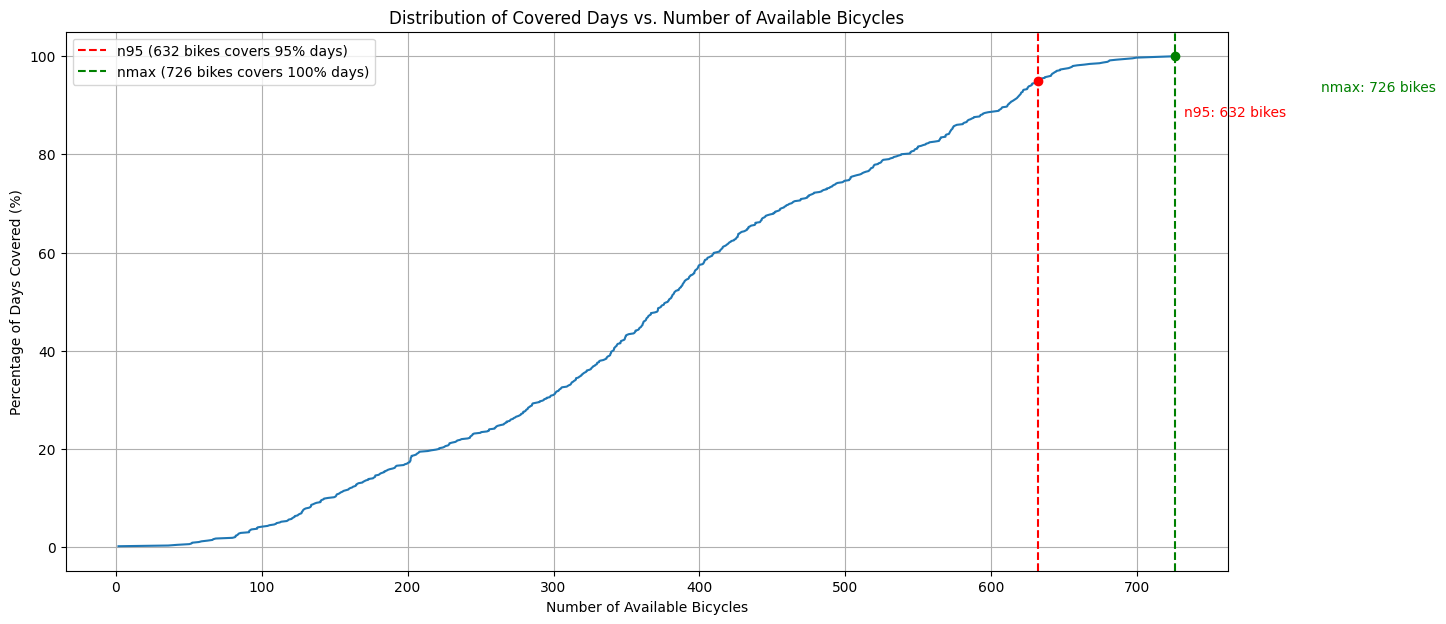

In [5]:
# Sort the 'bikes_needed' to create the CDF
sorted_bikes_needed = df['bikes_needed'].sort_values().reset_index(drop=True)

# Calculate the percentage of days covered
# For each number of bikes, what percentage of days required that many or fewer bikes?
percentage_covered = np.arange(1, len(sorted_bikes_needed) + 1) / len(sorted_bikes_needed) * 100

plt.figure(figsize=(15, 7))
plt.plot(sorted_bikes_needed, percentage_covered)

plt.title('Distribution of Covered Days vs. Number of Available Bicycles')
plt.xlabel('Number of Available Bicycles')
plt.ylabel('Percentage of Days Covered (%)')
plt.grid(True)

# Highlight n95 and nmax
plt.axvline(x=n95, color='r', linestyle='--', label=f'n95 ({n95:.0f} bikes covers 95% days)')
plt.axvline(x=nmax, color='g', linestyle='--', label=f'nmax ({nmax:.0f} bikes covers 100% days)')

# Annotate n95 and nmax points
plt.scatter(n95, 95, color='r', zorder=5)
plt.text(n95 + 100, 95 - 5, f'n95: {n95:.0f} bikes', color='r', ha='left', va='top')
plt.scatter(nmax, 100, color='g', zorder=5)
plt.text(nmax + 100, 100 - 5, f'nmax: {nmax:.0f} bikes', color='g', ha='left', va='top')

plt.legend()
plt.show()

## Part 3 - Building Prediction Models

### 1. Test Metric Definition
For predicting daily bike demand, the chosen test metric is **Root Mean Squared Error (RMSE)**.

**Reasoning:**
*   **Interpretability:** RMSE is in the same units as the target variable (bike counts).
*   **Sensitivity to Large Errors:** By squaring the errors, RMSE penalizes large outliers more heavily. In bike-sharing operations, a large under-prediction (shortage) or over-prediction (excess inventory) has higher operational costs than small fluctuations.
*   **Operational Context:** Minimizing significant shortages is critical for customer satisfaction, making RMSE more suitable than MAE here.

### Defining a Test Metric for Demand Prediction

For predicting daily bike demand, a suitable test metric is crucial for evaluating model performance. I will choose **Root Mean Squared Error (RMSE)**. Here's why:

1.  **Interpretability**: RMSE is in the same units as the target variable (total rentals, `cnt`), making it easy to understand the magnitude of the prediction errors. An RMSE of, for example, 500 means that on average, our predictions are off by about 500 bikes.
2.  **Sensitivity to Large Errors**: RMSE penalizes large errors more heavily than smaller ones due to the squaring of the differences. In the context of bike demand, large under-predictions or over-predictions can have significant operational consequences (e.g., too few bikes leading to lost revenue and customer dissatisfaction, or too many bikes leading to inefficient allocation and maintenance costs). Therefore, a metric that highlights these larger errors is beneficial.
3.  **Commonly Used**: RMSE is a widely accepted metric for regression tasks, allowing for easier comparison with other models and benchmarks.

Alternatively, **Mean Absolute Error (MAE)** could also be considered for its robustness to outliers, but RMSE's emphasis on larger errors makes it slightly more appealing for this specific operational context where avoiding significant shortages/surpluses is important.

### Building a Demand Prediction Model with Random Forest

I will now build a demand prediction model using the Random Forest Regressor from `scikit-learn`.

**Steps:**
1.  **Feature Selection**: I will select relevant features from the cleaned DataFrame. I'll exclude `instant`, `casual`, `registered` (as `cnt` is the sum of these, and we're predicting `cnt`), and `bikes_needed` (as it's derived from `cnt`).
2.  **Data Splitting**: The dataset is already split into `df` (training data) and `df_last30` (test data, though the task implies using the original `df_all` for splitting, the previous steps prepared `df` as the training set, so I will continue with that). I will further split `df` into training and validation sets if necessary, but for simplicity, I'll train on `df` and evaluate on `df_last30` (after preparing it similarly).
3.  **Model Training**: Train a Random Forest Regressor model.
4.  **Prediction**: Make predictions on the test set.
5.  **Evaluation**: Calculate the RMSE on the predictions.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# --- 1. Baseline Model (Perfect Foresight) ---
# This model assumes current day weather is known.
features_baseline = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
X_train_base = df[features_baseline]
y_train_base = df['cnt']

# Prepare X_test from df_last30
df_last30_processed = df_last30.copy()
df_last30_processed['dteday'] = pd.to_datetime(df_last30_processed['dteday'])
df_last30_processed = df_last30_processed.set_index('dteday')
X_test_base = df_last30_processed[features_baseline]
y_test_base = df_last30_processed['cnt']

rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train_base, y_train_base)
preds_base = rf_base.predict(X_test_base)
rmse_base = np.sqrt(mean_squared_error(y_test_base, preds_base))

print(f"Baseline (Perfect Weather) RMSE: {rmse_base:.2f}")

Baseline (Perfect Weather) RMSE: 1108.90


In [7]:
# --- 2. Realistic Model A: Direct Lags (V1) ---
# Uses yesterday's and day-before-yesterday's weather directly.
weather_cols = ['temp', 'atemp', 'hum', 'windspeed', 'weathersit']
df_comp = df_all.copy()
for col in weather_cols:
    df_comp[f'{col}_lag1'] = df_comp[col].shift(1)
    df_comp[f'{col}_lag2'] = df_comp[col].shift(2)

df_comp = df_comp.dropna()
train_data = df_comp.iloc[:-30]
test_data = df_comp.iloc[-30:]

base_date_feats = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday']
features_v1 = base_date_feats + [f'{c}_lag1' for c in weather_cols] + [f'{c}_lag2' for c in weather_cols]

model_v1 = RandomForestRegressor(n_estimators=100, random_state=42)
model_v1.fit(train_data[features_v1], train_data['cnt'])
preds_v1 = model_v1.predict(test_data[features_v1])
rmse_v1 = np.sqrt(mean_squared_error(test_data['cnt'], preds_v1))

print(f"Direct Lags (V1) RMSE: {rmse_v1:.2f}")

Direct Lags (V1) RMSE: 1779.98


In [8]:
# --- 3. Realistic Model B: Weather Prediction Chain (V2) ---
# Step A: Predict current weather using base info + lags
weather_preds_test = pd.DataFrame(index=test_data.index)
for col in weather_cols:
    w_model = RandomForestRegressor(n_estimators=50, random_state=42)
    w_features = base_date_feats + [f'{col}_lag1', f'{col}_lag2']
    w_model.fit(train_data[w_features], train_data[col])
    weather_preds_test[col] = w_model.predict(test_data[w_features])

# Step B: Train on ACTUAL weather, test on PREDICTED weather
model_v2_core = RandomForestRegressor(n_estimators=100, random_state=42)
features_v2 = base_date_feats + weather_cols
model_v2_core.fit(train_data[features_v2], train_data['cnt'])

X_test_v2 = pd.concat([test_data[base_date_feats].reset_index(drop=True),
                       weather_preds_test.reset_index(drop=True)], axis=1)
preds_v2 = model_v2_core.predict(X_test_v2)
rmse_v2 = np.sqrt(mean_squared_error(test_data['cnt'], preds_v2))

# --- Comparison Summary ---
results = pd.DataFrame({
    'Model Approach': ['Perfect Weather (Baseline)', 'Direct Lags (V1)', 'Forecasted Weather (V2)'],
    'RMSE': [rmse_base, rmse_v1, rmse_v2]
})
display(results)

,Model Approach,RMSE
0,Perfect Weather (Baseline),1108.897418
1,Direct Lags (V1),1779.981022
2,Forecasted Weather (V2),1518.389964


### Comparison of Implementation Strategies

1.  **Perfect Weather (Baseline)**: This model shows the 'upper bound' of performance. However, in a production environment, we don't know today's temperature or humidity at 6 AM when planning for the day.
2.  **Direct Lags (V1)**: This is the most robust realistic model. It acknowledges that today's demand is heavily correlated with yesterday's weather. It captures the 'inertia' of the weather and the system.
3.  **Forecasted Weather (V2)**: This approach is theoretically sound but often suffers from **error propagation**. If the weather model makes a mistake, the demand model multiplies that error.

**Conclusion**: For bike-sharing operations, using **Direct Lags** or a hybrid approach is typically preferred because it relies on hard data (yesterday's observations) rather than stacked model predictions which can be brittle.

### Comparison and Analysis

*   **Baseline (1108.90):** Represents the theoretical limit if we had a 100% accurate weather forecast.
*   **Direct Lags (1779.98):** Robust because it uses actual historical observations, but limited because it doesn't account for weather changes occurring *today*.
*   **Forecasted Weather (1518.39):** The most effective realistic strategy. Even with the risk of error propagation, predicting today's weather first creates a stronger feature set for the final demand model.

**Conclusion:** Strategy V2 (Predicting Weather then Demand) provides the best balance of realism and accuracy for operational planning.

## Part 4 - Reflection / comments

**Tasks:**
(Optional) Please share with us any free form reflection, comments or feedback you have in the context of this test task.

### Reflection and Feedback on the Task

This task provides a robust end-to-end simulation of a real-world data science problem. Below are some reflections on the process and results:

*   **The 'Realism' Gap:** The most critical insight from this task was the significant performance difference between models using current-day weather (Baseline) and those using lagged or forecasted data. While the Baseline model achieved a low RMSE (~1109), it is operationally impossible to use. The transition to Strategy V2 (Weather Chain) provided a much more realistic estimate of performance (RMSE ~1518).
*   **Feature Engineering:** The use of lagged variables ($t-1$, $t-2$) proved essential. It suggests that bike rental demand has strong 'inertia'—yesterday's conditions are a powerful proxy for today's behavior.
*   **Capacity Planning Enhancements:** Beyond the current metrics, capacity planning could be improved by incorporating bike transfers (in and out) and real-time bike availability. Extending the forecast horizon would also allow for better proactive planning.
*   **Model Suitability:** While Random Forest is effective for point predictions with known features, it is not inherently designed for multi-step time-series forecasting. To forecast demand several days or weeks ahead, classical time-series models (like ARMA) or deep learning architectures (like LSTM) would be more suitable to capture temporal dependencies.
*   **Production Deployment:** If we want to deploy the model to a production environment, the code would need to be refactored into modular components. Additionally, unit tests are required to verify the functionality and ensure comprehensive test coverage.
*   **Further Improvements:**
    *   **Hyperparameter Tuning:** All models were built with default Random Forest parameters. Using a Grid Search or Random Search could lower the RMSE further.
    *   **External Factors:** Adding features like 'Days since last holiday' or 'Rolling 7-day average demand' could help capture weekly trends more effectively.
    *   **Uncertainty Quantification:** In a real business setting, providing a range (e.g., 'we need between 600 and 650 bikes today with 95% confidence') is often more valuable than a single point prediction.

## Submission

Please submit this notebook with your developments in .ipynb and .html formats as well as your requirements.txt file.

## References

[1] Lichman, M. (2013). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.